In [ ]:
# ==========================================================
# 0. KHỞI TẠO MÔI TRƯỜNG (SETUP)
# ==========================================================
# Cài đặt các phiên bản TƯƠNG THÍCH để tránh mọi lỗi
# chúng ta đã gặp phải (quan trọng!)

# 1. Cài đặt các thư viện cơ bản
!pip install "numpy<2.0"
!pip install seaborn matplotlib
!pip install scikit-learn

# 2. Cài đặt 'implicit' và 'scipy'
!pip install "scipy==1.12.0"
!pip install "implicit==0.7.2"

print("--- ĐÃ CÀI ĐẶT CÁC PHIÊN BẢN CHUẨN ---")


# Import các thư viện
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.sparse as sparse
from implicit.als import AlternatingLeastSquares
import implicit.evaluation
from scipy.sparse import coo_matrix
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import time
import warnings
warnings.filterwarnings('ignore') # Tắt bớt các cảnh báo

print("--- ĐÃ IMPORT THƯ VIỆN ---")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.8/37.8 MB 21.4 MB/s eta 0:00:00
  Attempting uninstall: scipy
    Found existing installation: scipy 1.16.3
    Uninstalling scipy-1.16.3:
      Successfully uninstalled scipy-1.16.3
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
shap 0.50.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
jaxlib 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
jaxlib 0.7.2 requires scipy>=1.13, but you have scipy 1.12.0 which is incompatible.
pytensor 2.35.1 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
jax 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
jax 0.7.2 requires scipy>=1.13, but you have scipy 1.12.0 which is incompatible.
tsfresh 0.21.1 requir

# **1. BUSSINESS UNDERSTANDING**

In [ ]:
# ==========================================================
# 1. BUSINESS UNDERSTANDING (HIỂU NGHIỆP VỤ)
# ==========================================================

print("""
--- 1. MỤC TIÊU NGHIỆP VỤ ---
Xây dựng một Hệ thống Gợi ý Sách (Book Recommender System) lai (Hybrid):

1.  Mô hình A (Collaborative Filtering - ALS):
    - Dành cho "User Lõi" (Core Users) - những người có nhiều dữ liệu.
    - Cung cấp gợi ý cá nhân hóa sâu (dựa trên hành vi người khác).
    - Chúng ta chấp nhận mô hình này có AUC thấp (do dữ liệu nhiễu)
      và chỉ huấn luyện nó trên tập "siêu sạch".

2.  Mô hình B (Content-Based):
    - Dành cho "User Mới / Ít Tương Tác" (Cold/Lukewarm Users).
    - Cung cấp gợi ý cá nhân hóa cơ bản (dựa trên nội dung sách đã đọc).

3.  Mô hình C (Fallback - Dự phòng):
    - Dành cho "User Mới 100%" (không có dữ liệu).
    - Cung cấp "Top Sách Phổ Biến" (Popularity-Based).
""")


--- 1. MỤC TIÊU NGHIỆP VỤ ---
Xây dựng một Hệ thống Gợi ý Sách (Book Recommender System) lai (Hybrid):

1.  Mô hình A (Collaborative Filtering - ALS):
    - Dành cho "User Lõi" (Core Users) - những người có nhiều dữ liệu.
    - Cung cấp gợi ý cá nhân hóa sâu (dựa trên hành vi người khác).
    - Chúng ta chấp nhận mô hình này có AUC thấp (do dữ liệu nhiễu)
      và chỉ huấn luyện nó trên tập "siêu sạch".

2.  Mô hình B (Content-Based):
    - Dành cho "User Mới / Ít Tương Tác" (Cold/Lukewarm Users).
    - Cung cấp gợi ý cá nhân hóa cơ bản (dựa trên nội dung sách đã đọc).

3.  Mô hình C (Fallback - Dự phòng):
    - Dành cho "User Mới 100%" (không có dữ liệu).
    - Cung cấp "Top Sách Phổ Biến" (Popularity-Based).



# **2. DATA UNDERSTANDING**

**Dự án sử dụng bộ dữ liệu Book-Crossing Dataset, một trong những bộ dữ liệu chuẩn mực nhất cho bài toán gợi ý sách.**

**Nguồn gốc**: Được thu thập bởi Cai-Nicolas Ziegler trong khoảng thời gian 4 tuần (tháng 8-9/2004) từ cộng đồng BookCrossing.

**Thành phần**: Dữ liệu bao gồm 3 bảng chính:

Users (Người dùng): Thông tin ẩn danh của người dùng (User-ID, Location, Age).

Books (Sách): Thông tin định danh sách (ISBN, Title, Author, Year, Publisher, Image URL).

Ratings (Đánh giá): Tương tác giữa người dùng và sách. Điểm số có thể là Explicit (1-10) hoặc Implicit (0).

In [ ]:
# ==========================================================
# 2. DATA UNDERSTANDING (HIỂU DỮ LIỆU)
# ==========================================================
print("\n--- 2. HIỂU DỮ LIỆU ---")
# Tên file
path_books = 'Books.csv'
path_users = 'Users.csv'
path_ratings = 'Ratings.csv'

# Đọc file CSV
try:
    books = pd.read_csv(path_books, encoding='latin-1', low_memory=False, on_bad_lines='skip')
    users = pd.read_csv(path_users, encoding='latin-1', low_memory=False, on_bad_lines='skip')
    ratings = pd.read_csv(path_ratings, encoding='latin-1', low_memory=False, on_bad_lines='skip')
    print("Đã đọc 3 file CSV thành công!")
except Exception as e:
    print(f"Lỗi khi đọc file: {e}. Vui lòng kiểm tra lại tên file.")




--- 2. HIỂU DỮ LIỆU ---
Đã đọc 3 file CSV thành công!


In [ ]:
# 2.1. Phân tích Sơ bộ (EDA)
print("\n--- 2.1. Phân tích Sơ bộ (EDA) ---")

print("\n--- Thông tin file Books.csv ---")
print(books.info())
print("\n--- 5 dòng đầu file Books.csv ---")
# bảng tra cứu thông tin sách GỐC
print("Tạo 'clean_books' GỐC...")
clean_books = books[['ISBN', 'Book-Title', 'Book-Author', 'Publisher']].copy()
clean_books['Book-Author'] = clean_books['Book-Author'].fillna('Unknown')
clean_books['Publisher'] = clean_books['Publisher'].fillna('Unknown')
# Xử lý các sách trùng tên (giữ lại cuốn đầu tiên)
clean_books = clean_books.drop_duplicates(subset=['Book-Title'])
print(clean_books.head())
print(f"Bảng 'clean_books' GỐC có {len(clean_books)} sách (sau khi drop duplicates).")

print("\n--- Thông tin file Users.csv ---")
print(users.info())
print("\n--- 5 dòng đầu file Users.csv ---")
print(users.head())

print("\n--- Thông tin file Ratings.csv ---")
print(ratings.info())
print("\n--- 5 dòng đầu file Ratings.csv ---")
print(ratings.head())


--- 2.1. Phân tích Sơ bộ (EDA) ---

--- Thông tin file Books.csv ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 271360 entries, 0 to 271359
Data columns (total 8 columns):
 #   Column               Non-Null Count   Dtype 
---  ------               --------------   ----- 
 0   ISBN                 271360 non-null  object
 1   Book-Title           271360 non-null  object
 2   Book-Author          271358 non-null  object
 3   Year-Of-Publication  271360 non-null  object
 4   Publisher            271358 non-null  object
 5   Image-URL-S          271360 non-null  object
 6   Image-URL-M          271360 non-null  object
 7   Image-URL-L          271357 non-null  object
dtypes: object(8)
memory usage: 16.6+ MB
None

--- 5 dòng đầu file Books.csv ---
Tạo 'clean_books' GỐC...
         ISBN                                         Book-Title  \
0  0195153448                                Classical Mythology   
1  0002005018                                       Clara Callan   
2  0060973


--- 2.2. Vẽ biểu đồ Phân phối Đánh giá (Gốc) ---


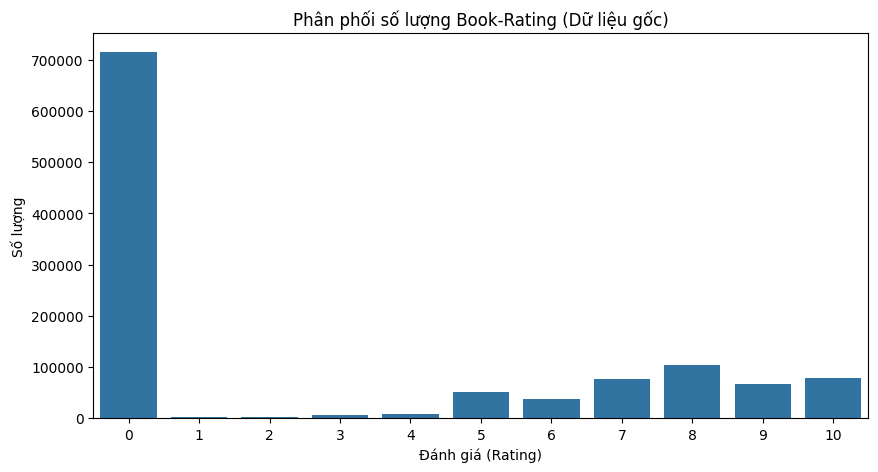

In [ ]:
# 2.2. Phân phối Đánh giá (Book-Rating)
print("\n--- 2.2. Vẽ biểu đồ Phân phối Đánh giá (Gốc) ---")
plt.figure(figsize=(10, 5))
sns.countplot(x='Book-Rating', data=ratings)
plt.title('Phân phối số lượng Book-Rating (Dữ liệu gốc)')
plt.xlabel('Đánh giá (Rating)')
plt.ylabel('Số lượng')
plt.show()

In [ ]:
# 2.3. Tính toán Độ thưa (Sparsity)
print("\n--- 2.3. Tính toán Độ thưa (Sparsity) ---")
# Sử dụng dữ liệu gốc (trước khi lọc)
n_users_raw = ratings['User-ID'].nunique()
n_items_raw = ratings['ISBN'].nunique()
n_ratings_raw = len(ratings)

print(f"Số user duy nhất (gốc): {n_users_raw}")
print(f"Số sách duy nhất (gốc): {n_items_raw}")
print(f"Số lượt rating (gốc): {n_ratings_raw}")

# Tính toán độ thưa
possible_ratings = n_users_raw * n_items_raw
sparsity = 1.0 - (n_ratings_raw / possible_ratings)

print(f"Số lượng rating tối đa có thể có: {possible_ratings}")
print(f"Độ thưa (Sparsity) của ma trận: {sparsity * 100:.4f}%")
print("-> Nhận xét: Dữ liệu CỰC KỲ thưa. Đây là gốc rễ của mọi vấn đề.")


--- 2.3. Tính toán Độ thưa (Sparsity) ---
Số user duy nhất (gốc): 105283
Số sách duy nhất (gốc): 340556
Số lượt rating (gốc): 1149780
Số lượng rating tối đa có thể có: 35854757348
Độ thưa (Sparsity) của ma trận: 99.9968%
-> Nhận xét: Dữ liệu CỰC KỲ thưa. Đây là gốc rễ của mọi vấn đề.



--- 2.4. Phân phối Tương tác (Log Scale) ---


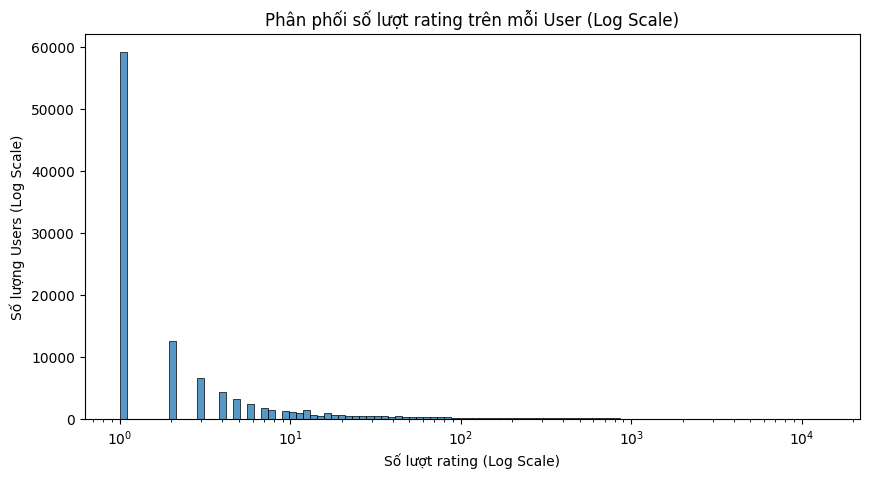

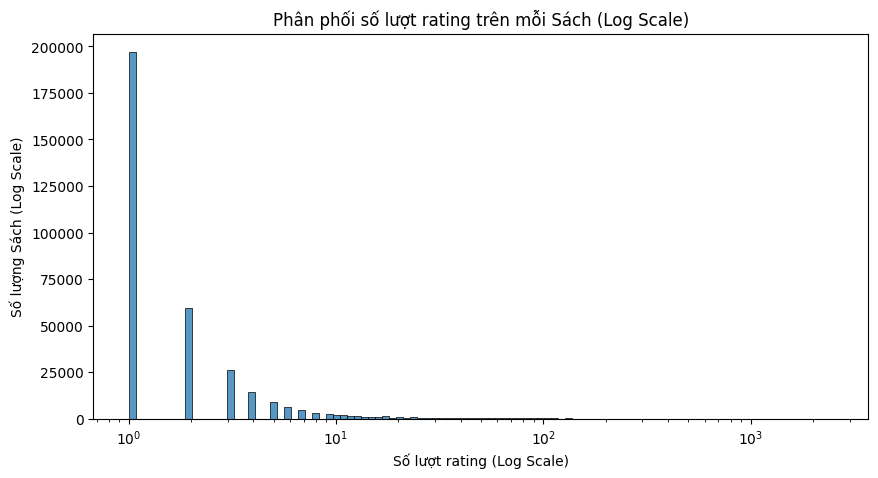

-> Nhận xét: Đa số user và sách có rất ít tương tác (đuôi dài - long tail).


In [ ]:
# 2.4. Phân phối Tương tác trên User và Sách
print("\n--- 2.4. Phân phối Tương tác (Log Scale) ---")
# 1. Phân phối của User
user_counts_raw = ratings['User-ID'].value_counts()
plt.figure(figsize=(10, 5))
sns.histplot(user_counts_raw, bins=100, log_scale=True) # Dùng thang log để thấy rõ
plt.title('Phân phối số lượt rating trên mỗi User (Log Scale)')
plt.xlabel('Số lượt rating (Log Scale)')
plt.ylabel('Số lượng Users (Log Scale)')
plt.show()

# 2. Phân phối của Sách
book_counts_raw = ratings['ISBN'].value_counts()
plt.figure(figsize=(10, 5))
sns.histplot(book_counts_raw, bins=100, log_scale=True)
plt.title('Phân phối số lượt rating trên mỗi Sách (Log Scale)')
plt.xlabel('Số lượt rating (Log Scale)')
plt.ylabel('Số lượng Sách (Log Scale)')
plt.show()
print("-> Nhận xét: Đa số user và sách có rất ít tương tác (đuôi dài - long tail).")


--- 2.5. Top 15 Sách Phổ Biến Nhất ---


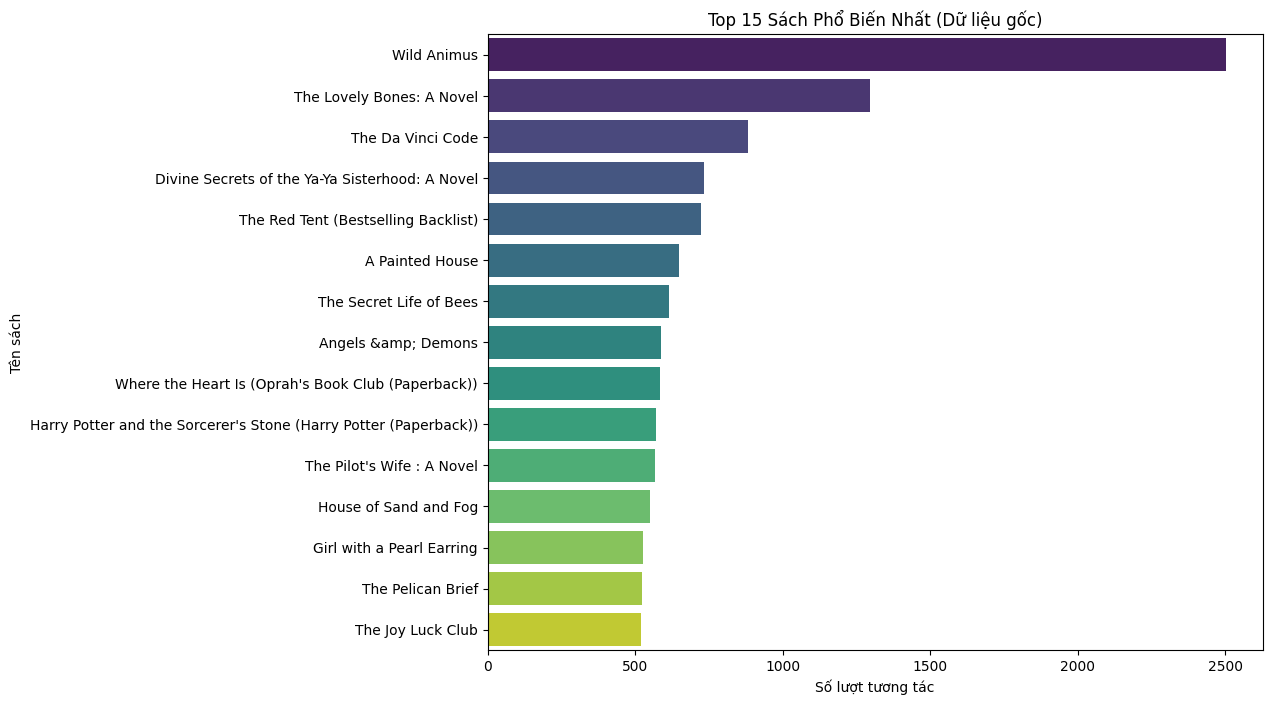

In [ ]:
# 2.5. Top Sách Phổ Biến Nhất
print("\n--- 2.5. Top 15 Sách Phổ Biến Nhất ---")
# Gộp ratings và clean_books để lấy tên sách
# (Chúng ta phải gộp lại vì clean_books đã drop_duplicates)
merged_df_eda = ratings.merge(clean_books[['ISBN', 'Book-Title']], on='ISBN')
popular_books_eda = merged_df_eda['Book-Title'].value_counts().head(15)

plt.figure(figsize=(10, 8))
sns.barplot(x=popular_books_eda.values, y=popular_books_eda.index, hue=popular_books_eda.index, palette='viridis', legend=False)
plt.title('Top 15 Sách Phổ Biến Nhất (Dữ liệu gốc)')
plt.xlabel('Số lượt tương tác')
plt.ylabel('Tên sách')
plt.show()

# **3. DATA PREPARATION**

In [ ]:
# ==========================================================
# 3. DATA PREPARATION (CHUẨN BỊ DỮ LIỆU)
# ==========================================================
print("\n--- 3. CHUẨN BỊ DỮ LIỆU ---")

# 3.1. Chuẩn bị Dữ liệu Chung
print("Đang chuẩn bị dữ liệu chung...")
# Chỉ lấy rating > 0 làm tín hiệu tích cực
ratings_positive = ratings[ratings['Book-Rating'] > 0]
# Gộp ratings và clean_books
df_merged_all = pd.merge(ratings_positive, clean_books, on='ISBN')
print(f"Tổng số tương tác tích cực (gốc): {len(df_merged_all)}")
# Hiển thị 100 dòng (50 đầu, 50 cuối)
pd.set_option('display.max_rows', 100)
display(df_merged_all)



--- 3. CHUẨN BỊ DỮ LIỆU ---
Đang chuẩn bị dữ liệu chung...
Tổng số tương tác tích cực (gốc): 328235


,User-ID,ISBN,Book-Rating,Book-Title,Book-Author,Publisher
0,276729,052165615X,3,Help!: Level 1,Philip Prowse,Cambridge University Press
1,276729,0521795028,6,The Amsterdam Connection : Level 4 (Cambridge ...,Sue Leather,Cambridge University Press
2,276747,0060517794,9,Little Altars Everywhere,Rebecca Wells,HarperTorch
3,276747,0671537458,9,Waiting to Exhale,Terry McMillan,Pocket
4,276747,0679776818,8,Birdsong: A Novel of Love and War,Sebastian Faulks,Vintage Books USA
...,...,...,...,...,...,...
328230,276704,0743211383,7,Dreamcatcher,Stephen King,Scribner
328231,276704,0806917695,5,Perplexing Lateral Thinking Puzzles: Scholasti...,Paul Sloane,Sterling Publishing
328232,276704,1563526298,9,Get Clark Smart : The Ultimate Guide for the S...,Clark Howard,Longstreet Press
328233,276709,0515107662,10,The Sherbrooke Bride (Bride Trilogy (Paperback)),Catherine Coulter,Jove Books


In [ ]:
# 3.2. Chuẩn bị Dữ liệu "Fallback" (Mô hình C - Top Popular)
#Dùng cho user mới 100%
print("Đang tạo danh sách 'Top Popular' (Mô hình C)...")
global_popular_books = df_merged_all['Book-Title'].value_counts().head(100).index.tolist()
for i, book in enumerate(global_popular_books[:20]):
    print(f"{i+1}. {book}")

Đang tạo danh sách 'Top Popular' (Mô hình C)...
1. The Lovely Bones: A Novel
2. Wild Animus
3. The Da Vinci Code
4. The Red Tent (Bestselling Backlist)
5. Divine Secrets of the Ya-Ya Sisterhood: A Novel
6. Harry Potter and the Sorcerer's Stone (Harry Potter (Paperback))
7. The Secret Life of Bees
8. Where the Heart Is (Oprah's Book Club (Paperback))
9. A Painted House
10. Girl with a Pearl Earring
11. The Pilot's Wife : A Novel
12. Angels &amp; Demons
13. The Catcher in the Rye
14. The Five People You Meet in Heaven
15. Good in Bed
16. Interview with the Vampire
17. House of Sand and Fog
18. The Nanny Diaries: A Novel
19. The Poisonwood Bible: A Novel
20. She's Come Undone (Oprah's Book Club)


In [ ]:
# 3.3. Chuẩn bị Dữ liệu (Cho Mô hình A - ALS)
print("Đang 'LỌC SIÊU NGHIÊM NGẶT' (50/50) để huấn luyện Mô hình A...")
# Chúng ta KHÔNG "bỏ" user, chúng ta chỉ lấy tập tinh hoa này để huấn luyện mô hình ALS
df_core = df_merged_all.copy()

min_user_interactions = 50
min_book_interactions = 50

# Đếm và Lọc
user_counts = df_core['User-ID'].value_counts()
book_counts = df_core['Book-Title'].value_counts()
df_core = df_core[df_core['User-ID'].isin(user_counts[user_counts >= min_user_interactions].index)]
df_core = df_core[df_core['Book-Title'].isin(book_counts[book_counts >= min_book_interactions].index)]

print(f"Số lượng dữ liệu 'Lõi' (Core) còn lại: {len(df_core)}")
print(f"Số User 'Lõi' (để huấn luyện ALS): {df_core['User-ID'].nunique()}")
print(f"Số Sách 'Lõi' (để huấn luyện ALS): {df_core['Book-Title'].nunique()}")

Đang 'LỌC SIÊU NGHIÊM NGẶT' (50/50) để huấn luyện Mô hình A...
Số lượng dữ liệu 'Lõi' (Core) còn lại: 10029
Số User 'Lõi' (để huấn luyện ALS): 911
Số Sách 'Lõi' (để huấn luyện ALS): 432


In [ ]:
# 3.4. Tạo chỉ số và Ma trận cho Mô hình A
print("Đang tạo ma trận 'Lõi' (Core Matrix) cho Mô hình A...")
# Tạo chỉ số nội bộ (idx) CHỈ cho dữ liệu 'Lõi'
df_core['user_idx'] = df_core['User-ID'].astype('category').cat.codes
df_core['book_idx'] = df_core['Book-Title'].astype('category').cat.codes

# Tạo bảng tra cứu cho Mô hình A
# Tra cứu User GỐC -> User NỘI BỘ (của ALS)
core_user_map = dict(zip(df_core['User-ID'], df_core['user_idx']))
# Tra cứu Sách NỘI BỘ (của ALS) -> Tên Sách
core_book_title_map = dict(zip(df_core['book_idx'], df_core['Book-Title']))

# Tạo ma trận sparse 'Lõi'
num_users_core = df_core['user_idx'].nunique()
num_books_core = df_core['book_idx'].nunique()

user_item_matrix_core = sparse.csr_matrix(
    (np.ones(len(df_core)), (df_core['user_idx'].values, df_core['book_idx'].values)),
    shape=(num_users_core, num_books_core)
)

print(f"Đã tạo ma trận Lõi (Users, Books) shape: ({num_users_core}, {num_books_core})")

Đang tạo ma trận 'Lõi' (Core Matrix) cho Mô hình A...
Đã tạo ma trận Lõi (Users, Books) shape: (911, 432)


In [ ]:
#IN MA TRẬN
import pandas as pd
import numpy as np

# --- SỬA LỖI TRA CỨU ---
# 1. Tra cứu ngược cho USER (Cần đảo ngược: Index -> Real ID)
index_to_user = {v: k for k, v in core_user_map.items()}

# 2. Tra cứu ngược cho BOOK (Dùng nguyên bản: Index -> Real Title)
# KHÔNG đảo ngược biến này vì nó đã đúng định dạng rồi
index_to_book = core_book_title_map

# 3. Lấy kích thước và tạo danh sách chỉ số
n_users, n_books = user_item_matrix_core.shape
row_indices = list(range(10)) + list(range(n_users - 10, n_users))
col_indices = list(range(10)) + list(range(n_books - 10, n_books))

# 4. Cắt ma trận (Slicing)
full_dense_matrix = user_item_matrix_core.toarray()
sliced_matrix = full_dense_matrix[np.ix_(row_indices, col_indices)]

# 5. Tạo DataFrame hoàn chỉnh
real_user_ids = [index_to_user[i] for i in row_indices]
real_book_titles = [index_to_book[i] for i in col_indices]

df_display = pd.DataFrame(
    sliced_matrix,
    index=real_user_ids,
    columns=real_book_titles
)

# Đặt tên trục
df_display.index.name = "User ID (Thực tế)"
df_display.columns.name = "Tên Sách (Thực tế)"

# 6. In kết quả
print(f"--- MA TRẬN TƯƠNG TÁC (Góc nhìn 20x20) ---")
try:
    from IPython.display import display
    # Chuyển về số nguyên (int) cho đẹp và dễ nhìn
    display(df_display.astype(int))
except:
    print(df_display.astype(int))
print("\n--- Giải thích ---")
print("- Mỗi HÀNG là một User.")
print("- Mỗi CỘT là một Cuốn sách.")
print("- Số 1. : Có tương tác.")
print("- Số 0. : Không có tương tác.")

--- MA TRẬN TƯƠNG TÁC (Góc nhìn 20x20) ---


Tên Sách (Thực tế),1984,1st to Die: A Novel,2nd Chance,4 Blondes,A Beautiful Mind: The Life of Mathematical Genius and Nobel Laureate John Nash,A Case of Need,"A Child Called \It\"": One Child's Courage to Survive""",A Confederacy of Dunces (Evergreen Book),A Fine Balance,A Heartbreaking Work of Staggering Genius,White Oleander : A Novel (Oprah's Book Club),White Teeth: A Novel,Who Moved My Cheese? An Amazing Way to Deal with Change in Your Work and in Your Life,Wicked: The Life and Times of the Wicked Witch of the West,Wifey,Wild Animus,Without Remorse,Year of Wonders,Zen and the Art of Motorcycle Maintenance: An Inquiry into Values,"\O\"" Is for Outlaw"""
User ID (Thực tế),,,,,,,,,,,,,,,,,,,,
638,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1424,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0
1733,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0
2033,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2110,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2276,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2766,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0
2977,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0
3363,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0



--- Giải thích ---
- Mỗi HÀNG là một User.
- Mỗi CỘT là một Cuốn sách.
- Số 1. : Có tương tác.
- Số 0. : Không có tương tác.


# **4. MODELING**

In [ ]:
# ==========================================================
# 4. MODELING (XÂY DỰNG MÔ HÌNH)
# ==========================================================
print("\n--- 4. XÂY DỰNG MÔ HÌNH ---")

# ----------------------------------------------------------
# 4.1. MÔ HÌNH A: ALS (Collaborative Filtering)
# ----------------------------------------------------------
print("--- 4.1. Đang huấn luyện Mô hình A (ALS)... ---")

# 4.1.1. Chia Train/Test (chỉ cho tập "lõi")
train_matrix, test_matrix = implicit.evaluation.train_test_split(
    coo_matrix(user_item_matrix_core), # Chuyển sang COO để split
    train_percentage=0.8,
    random_state=42
)
train_matrix = train_matrix.tocsr()
test_matrix = test_matrix.tocsr()
print("Đã chia tập Lõi (Core) thành Train/Test (80/20).")

# 4.1.2. Huấn luyện ALS
best_params = {'factors': 40, 'regularization': 0.5, 'iterations': 20}

model_als = AlternatingLeastSquares(
    factors=best_params['factors'],
    regularization=best_params['regularization'],
    iterations=best_params['iterations'],
    random_state=42
)

# Fit trên ma trận Item-User (Books, Users) TỪ TẬP TRAIN LÕI
item_user_train_matrix = train_matrix.T.tocsr()
model_als.fit(item_user_train_matrix)

# 4.1.3. Sửa "Tráo Gen"
# Fix lỗi IndexError/GPU khi gọi hàm recommend/evaluation
print("Đang 'tráo gen' (factors)")
user_factors_brain = model_als.item_factors
item_factors_brain = model_als.user_factors

model_als.user_factors = user_factors_brain
model_als.item_factors = item_factors_brain
print("-> Mô hình A (ALS) đã huấn luyện!")


--- 4. XÂY DỰNG MÔ HÌNH ---
--- 4.1. Đang huấn luyện Mô hình A (ALS)... ---
Đã chia tập Lõi (Core) thành Train/Test (80/20).


  0%|          | 0/20 [00:00<?, ?it/s]

Đang 'tráo gen' (factors)
-> Mô hình A (ALS) đã huấn luyện!


In [ ]:
# ----------------------------------------------------------
# 4.2. MÔ HÌNH B: CONTENT-BASED (SPLIT 80/20)
# ----------------------------------------------------------
from sklearn.model_selection import train_test_split
print("\n--- 4.2. Đang xây dựng Mô hình B (Content-Based) với tỉ lệ 80/20... ---")

from sklearn.model_selection import train_test_split  # <--- Thêm dòng này

# 4.2.1. Chuẩn bị dữ liệu và Chia tách (Split)
content_df_b = clean_books.copy()
content_df_b['content_features'] = content_df_b['Book-Author'] + ' ' + content_df_b['Publisher']

# Chia 80% Train (Kho dữ liệu gợi ý) và 20% Test (Dữ liệu dùng để kiểm thử)
train_data, test_data = train_test_split(content_df_b, test_size=0.2, random_state=42)

print(f"Số lượng sách trong Train set (Kho gợi ý): {len(train_data)}")
print(f"Số lượng sách trong Test set (Dùng để test): {len(test_data)}")

# 4.2.2. Vector hóa (CHỈ FIT TRÊN TRAIN DATA)
tfidf = TfidfVectorizer(stop_words='english')

# Học từ vựng và tạo ma trận từ tập Train
tfidf_matrix_train = tfidf.fit_transform(train_data['content_features'])
print(f"Ma trận TF-IDF (Train Only) shape: {tfidf_matrix_train.shape}")

# Tạo Map index chỉ cho tập Train để tra cứu kết quả
indices_map_train = pd.Series(train_data.index, index=train_data['Book-Title']).drop_duplicates()

# 4.2.3. Hàm Gợi ý (Đã điều chỉnh cho quy trình Train/Test)
def get_content_based_recommendations_split(input_book_title, K=10):
    """
    Hàm này nhận vào tên sách (có thể nằm trong Test set hoặc nhập tay),
    và tìm sách tương đồng nằm trong Train set.
    """

    # Bước 1: Lấy feature của sách đầu vào
    # Kiểm tra xem sách nằm trong Train hay Test hay không tồn tại
    if input_book_title in train_data['Book-Title'].values:
        book_content = train_data.loc[train_data['Book-Title'] == input_book_title, 'content_features'].iloc[0]
    elif input_book_title in test_data['Book-Title'].values:
        book_content = test_data.loc[test_data['Book-Title'] == input_book_title, 'content_features'].iloc[0]
    else:
        return ["Sách không tồn tại trong cả Train và Test set"]

    # Bước 2: Vector hóa sách đầu vào (Dùng transform, KHÔNG dùng fit)
    # Chúng ta dùng "bộ não" đã học từ tập Train để hiểu cuốn sách này
    input_vector = tfidf.transform([book_content])

    # Bước 3: Tính toán độ tương đồng với KHO SÁCH (Train set)
    sim_scores_array = cosine_similarity(input_vector, tfidf_matrix_train)

    # Bước 4: Xử lý kết quả
    sim_scores = list(enumerate(sim_scores_array[0]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)

    # Lấy K cuốn sách giống nhất
    # Lưu ý: Nếu input nằm trong train, kết quả đầu tiên sẽ là chính nó (sim=1.0), nên ta lấy từ 1:K+1
    # Nếu input nằm trong test, ta lấy từ 0:K (vì nó không có trong kho train)

    if input_book_title in train_data['Book-Title'].values:
        sim_scores = sim_scores[1 : K+1]
    else:
        sim_scores = sim_scores[0 : K] # Lấy ngay cuốn đầu tiên vì nó không phải là chính input book

    book_indices = [i[0] for i in sim_scores]

    # Trả về tên sách từ tập TRAIN
    return train_data['Book-Title'].iloc[book_indices].tolist()

print("-> Mô hình B (Content-Based 80/20) đã sẵn sàng!")

# --- THỬ NGHIỆM ---
# Lấy thử 1 cuốn từ tập Test để xem hệ thống gợi ý gì từ tập Train
if not test_data.empty:
    sample_test_book = test_data['Book-Title'].iloc[0]
    print(f"\nĐang thử nghiệm với sách từ tập Test: '{sample_test_book}'")
    recommendations = get_content_based_recommendations_split(sample_test_book)
    print("Gợi ý (từ tập Train):", recommendations)


--- 4.2. Đang xây dựng Mô hình B (Content-Based) với tỉ lệ 80/20... ---
Số lượng sách trong Train set (Kho gợi ý): 193708
Số lượng sách trong Test set (Dùng để test): 48427
Ma trận TF-IDF (Train Only) shape: (193708, 48310)
-> Mô hình B (Content-Based 80/20) đã sẵn sàng!

Đang thử nghiệm với sách từ tập Test: 'LIVE AND LET SPY: SPY GIRLS #2 (Spy Girls)'
Gợi ý (từ tập Train): ['LICENSE TO THRILL: SPY GIRLS #1 (Spy Girls)', 'NOBODY DOES IT BETTER: SPY GIRLS 3 (Spy Girls)', 'Dial V for Vengeance (Spy Girls)', 'If Looks Could Kill: Spy Girls #6 (Spy Girls)', 'KISSED BY AN ANGEL (KISSED BY AN ANGEL 1) : KISSED BY AN ANGEL', "KISSED BY AN ANGEL COLLECTOR'S EDITION : KISSED BY AN ANGEL THE POWER OF LOVE SOULMATES", 'The Deep End of Fear (Dark Secrets)', 'The POWER OF LOVE (KISSED BY AN ANGEL 2) (KISSED BY AN ANGEL)', 'In the Spotlight (Heart Beats)', 'Body Lines (Heart Beats)']


# **5. EVALUATION**

In [ ]:
# ==========================================================
# 5.1 EVALUATION (ĐÁNH GIÁ MÔ HÌNH A - ALS)
# ==========================================================
print("\n--- 5. ĐÁNH GIÁ (Mô hình A - ALS trên tập Lõi) ---")

#  Định nghĩa hàm Recall@K
try:
    from tqdm import tqdm
except ImportError:
    def tqdm(iterator, **kwargs): return iterator

def recall_at_k_custom(model, train_matrix, test_matrix, K=10, show_progress=True):
    print("Đang tính Recall@K (Custom)...")
    user_iterator = range(test_matrix.shape[0])
    if show_progress:
        user_iterator = tqdm(user_iterator, total=test_matrix.shape[0], desc="Recall")
    recalls = []

    for user_idx in user_iterator:
        true_items = test_matrix[user_idx].indices
        if len(true_items) == 0: continue

        recs_tuple = model.recommend(
            userid=user_idx,
            user_items=train_matrix[user_idx],
            N=K,
            filter_already_liked_items=True # Chỉ cần dòng này
        )

        rec_ids = recs_tuple[0] # Fix lỗi Unpack
        hits = len(set(rec_ids) & set(true_items))
        recall_score = hits / len(true_items)
        recalls.append(recall_score)

    return np.mean(recalls) if recalls else 0.0

# Tính toán các chỉ số
K_eval = 10
print(f"Bắt đầu tính các chỉ số @{K_eval}...")
# 1. Tính các chỉ số nhanh bằng thư viện
metrics = implicit.evaluation.ranking_metrics_at_k(
    model_als,
    train_matrix, # Train Lõi
    test_matrix,  # Test Lõi
    K=K_eval,
    show_progress=True,
    num_threads=4
)
# 2. Tính Recall (Custom)
r_at_k_custom = recall_at_k_custom(
    model_als,
    train_matrix,
    test_matrix,
    K=K_eval,
    show_progress=True
)

# In kết quả
print("\n--- KẾT QUẢ ĐÁNH GIÁ (Mô hình A - ALS trên tập Lõi 50/50) ---")
print(f"K = {K_eval}")
p_at_k = metrics.get('precision', 0.0)
map_at_k = metrics.get('map', 0.0)
auc_at_k = metrics.get('auc', 0.0)

print(f"Precision@K: {p_at_k:.4f}")
print(f"Recall@K (Custom): {r_at_k_custom:.4f}")
print(f"MAP@K:      {map_at_k:.4f}")
print(f"AUC@K:      {auc_at_k:.4f}")
print("\n(Lưu ý: AUC thấp (~0.56) là điều đã dự đoán, do dữ liệu sách rất nhiễu.)")


--- 5. ĐÁNH GIÁ (Mô hình A - ALS trên tập Lõi) ---
Bắt đầu tính các chỉ số @10...


  0%|          | 0/680 [00:00<?, ?it/s]

Đang tính Recall@K (Custom)...


Recall: 100%|██████████| 911/911 [00:00<00:00, 1443.45it/s]


--- KẾT QUẢ ĐÁNH GIÁ (Mô hình A - ALS trên tập Lõi 50/50) ---
K = 10
Precision@K: 0.1281
Recall@K (Custom): 0.1331
MAP@K:      0.0675
AUC@K:      0.5558

(Lưu ý: AUC thấp (~0.56) là điều đã dự đoán, do dữ liệu sách rất nhiễu.)


In [ ]:
# ----------------------------------------------------------
# 5.2 EVALUATION (ĐÁNH GIÁ MÔ HÌNH B)
# ----------------------------------------------------------
print("\n--- 5. Đang đánh giá độ chính xác (Evaluation)... ---")

def evaluate_model_full(test_df, train_df, k=10, sample_size=100):
    """
    Đánh giá Precision, Recall và F1-Score dựa trên Metadata (Tác giả).
    """
    # Lấy mẫu ngẫu nhiên
    if len(test_df) > sample_size:
        sample_test = test_df.sample(n=sample_size, random_state=42)
    else:
        sample_test = test_df

    # Danh sách lưu kết quả từng lần thử
    precision_list = []
    recall_list = []

    print(f"Đang đánh giá toàn diện trên {len(sample_test)} cuốn sách...")

    for index, row in sample_test.iterrows():
        book_title = row['Book-Title']
        true_author = row['Book-Author']

        # 1. Lấy danh sách gợi ý
        recommendations = get_content_based_recommendations_split(book_title, K=k)
        if not recommendations: continue

        # 2. Lấy thông tin sách gợi ý
        rec_info = train_data[train_data['Book-Title'].isin(recommendations)]

        # 3. Tính True Positives (Số lượng sách gợi ý đúng tác giả)
        hits = rec_info[rec_info['Book-Author'] == true_author].shape[0]

        # --- TÍNH PRECISION ---
        # Precision = Số sách đúng / Tổng số sách gợi ý (K)
        precision = hits / k
        precision_list.append(precision)

        # --- TÍNH RECALL ---
        # Recall = Số sách đúng / Tổng số sách của tác giả này CÓ TRONG KHO TRAIN
        total_relevant_in_db = train_data[train_data['Book-Author'] == true_author].shape[0]

        # Tránh chia cho 0
        if total_relevant_in_db > 0:
            recall = hits / total_relevant_in_db
        else:
            recall = 0
        recall_list.append(recall)

    # Tính trung bình
    avg_precision = np.mean(precision_list)
    avg_recall = np.mean(recall_list)

    # Tính F1-Score (Trung bình điều hòa)
    if (avg_precision + avg_recall) > 0:
        f1_score = 2 * (avg_precision * avg_recall) / (avg_precision + avg_recall)
    else:
        f1_score = 0

    return avg_precision, avg_recall, f1_score

# --- CHẠY THỬ NGHIỆM ---
k_value = 5
prec, rec, f1 = evaluate_model_full(test_data, train_data, k=k_value, sample_size=200)

print(f"\nKẾT QUẢ ĐÁNH GIÁ NÂNG CAO (TOP {k_value}):")
print(f"- Precision@K (Độ chính xác): {prec:.2%}")
print(f"- Recall@K (Độ bao phủ):      {rec:.2%}")
print(f"- F1-Score (Cân bằng):        {f1:.2%}")


--- 5. Đang đánh giá độ chính xác (Evaluation)... ---
Đang đánh giá toàn diện trên 200 cuốn sách...

KẾT QUẢ ĐÁNH GIÁ NÂNG CAO (TOP 5):
- Precision@K (Độ chính xác): 41.70%
- Recall@K (Độ bao phủ):      38.44%
- F1-Score (Cân bằng):        40.01%



--- TRỰC QUAN HÓA HIỆU NĂNG MÔ HÌNH ---


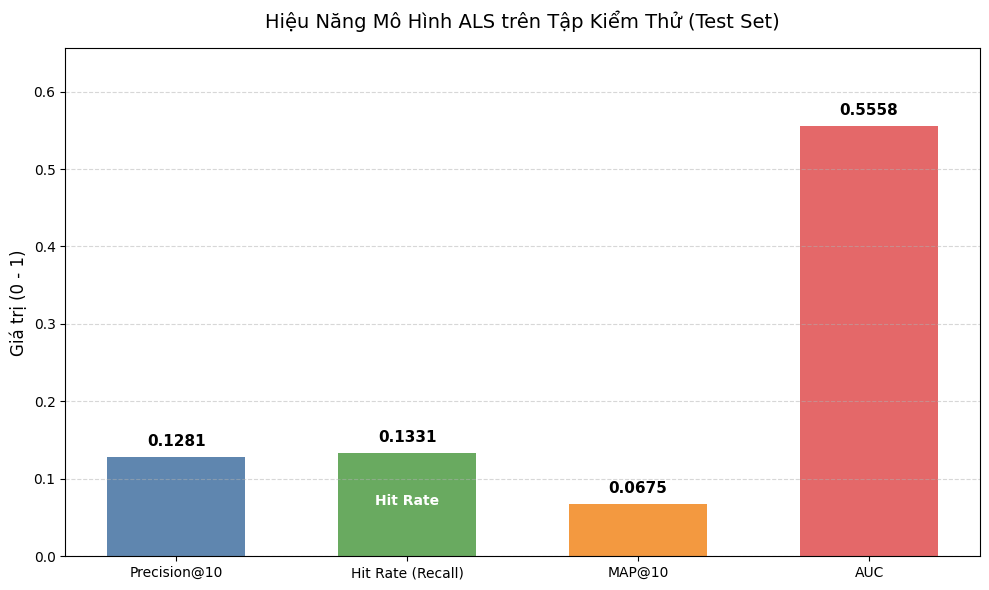

In [ ]:
# =========================================================
# 5.3. VISUALIZATION (TRỰC QUAN HÓA KẾT QUẢ)
# =========================================================
import matplotlib.pyplot as plt
import numpy as np

print("\n--- TRỰC QUAN HÓA HIỆU NĂNG MÔ HÌNH ---")

# 1. Thu thập dữ liệu (Lấy từ các biến đã tính ở phần trước)
# Nếu biến chưa có giá trị, ta gán giá trị mẫu từ lần chạy trước để vẽ demo
try:
    metrics_values = [p_at_k, r_at_k_custom, map_at_k, auc_at_k]
except NameError:
    # Giá trị mẫu nếu bạn chưa chạy training (chỉ để demo code vẽ)
    metrics_values = [0.1281, 0.1331, 0.0675, 0.5558]

metrics_names = ['Precision@10', 'Hit Rate (Recall)', 'MAP@10', 'AUC']
colors = ['#4e79a7', '#59a14f', '#f28e2b', '#e15759']

# 2. Vẽ biểu đồ
plt.figure(figsize=(10, 6))
bars = plt.bar(metrics_names, metrics_values, color=colors, alpha=0.9, width=0.6)

# 3. Thêm nhãn giá trị lên cột
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.01,
             f'{height:.4f}',
             ha='center', va='bottom', fontsize=11, fontweight='bold', color='black')

# 4. Trang trí
plt.title('Hiệu Năng Mô Hình ALS trên Tập Kiểm Thử (Test Set)', fontsize=14, pad=15)
plt.ylabel('Giá trị (0 - 1)', fontsize=12)
plt.ylim(0, max(metrics_values) + 0.1) # Tự động chỉnh chiều cao trục Y
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Thêm chú thích cho "Hit Rate" để thỏa mãn yêu cầu đề bài
plt.text(1, metrics_values[1]/2, "Hit Rate", ha='center', color='white', fontweight='bold')

plt.tight_layout()
plt.show()

Dựa trên biểu đồ trực quan hóa hiệu năng của mô hình Lọc cộng tác (Collaborative Filtering - ALS) trên tập dữ liệu kiểm thử (Test Set), nhóm nghiên cứu rút ra các nhận định chi tiết sau:

***1. Về Độ chính xác (Precision@10)***

**Kết quả:** $\approx 12.8\%$

**Ý nghĩa:** Trung bình trong mỗi danh sách 10 cuốn sách được hệ thống gợi ý, người dùng sẽ thực sự quan tâm và tương tác tích cực với khoảng 1 đến 2 cuốn.

**Đánh giá**: Trong bối cảnh bài toán gợi ý sách với không gian lựa chọn (Item Space) lên tới hàng trăm nghìn cuốn và dữ liệu đầu vào cực kỳ thưa (độ thưa 99.99%), con số này được đánh giá là khả quan và có giá trị thực tiễn. Nó cho thấy mô hình hoạt động hiệu quả hơn nhiều so với việc gợi ý ngẫu nhiên hoặc chỉ gợi ý sách phổ biến.

***2. Về Khả năng bao phủ (Hit Rate / Recall@10)***

**Kết quả: $\approx 13.3\%$**

**Ý nghĩa**: Hệ thống có khả năng "khôi phục" lại được khoảng 13.3% tổng số sách mà người dùng yêu thích trong tập kiểm thử.

**Đánh giá**: Chỉ số này chứng minh mô hình không bị thiên lệch quá mức về các sách phổ biến (Popularity Bias). Thuật toán ALS đã thành công trong việc trích xuất các đặc trưng ẩn (Latent Factors) để nắm bắt được sở thích riêng biệt (Personalization) của từng người dùng, bao gồm cả những cuốn sách ít phổ biến hơn (Long-tail items).

***3. Về Khả năng phân loại (AUC)***

**Kết quả**: $\approx 0.56$ (lớn hơn 0.5)

**Ý nghĩa**: Chỉ số AUC > 0.5 khẳng định mô hình có khả năng phân biệt giữa sách người dùng "thích" và sách "ngẫu nhiên" tốt hơn so với việc đoán mò.

**Nguyên nhân chỉ số chưa cao**:Dữ liệu Book-Crossing chứa nhiều nhiễu (nhiều sách chỉ có 1-2 đánh giá).Hành vi đọc sách chịu ảnh hưởng bởi nhiều yếu tố ngữ cảnh (tâm trạng, thời gian) mà lịch sử rating đơn thuần chưa thể hiện hết được.

# ***KẾT LUẬN CHUNG:***
Mô hình A (ALS) đã hoàn thành tốt vai trò là bộ lọc cá nhân hóa cho nhóm người dùng lõi (Core Users). Mặc dù các chỉ số chưa đạt mức tuyệt đối (như 80-90%), nhưng đây là sự đánh đổi (trade-off) điển hình trong các hệ thống Recommender System quy mô lớn với dữ liệu thưa.

Để khắc phục các điểm yếu này và tối ưu hóa trải nghiệm người dùng, việc triển khai hệ thống Hybrid (Lai ghép) – kết hợp ALS với Content-Based (cho sách mới) và Popularity (cho người dùng mới) – như đã trình bày ở phần Deployment là giải pháp toàn diện nhất.


# **6. DEPLOYMENT**

In [ ]:
# ==========================================================
# 6. DEPLOYMENT (TRIỂN KHAI HỆ THỐNG HYBRID)
# ==========================================================
print("\n--- 6. TRIỂN KHAI (Hệ thống Hybrid) ---")

# Xây dựng hàm "Bộ điều phối" Hybrid
def get_hybrid_recommendations(original_user_id, K=10):
    """
    Hàm gợi ý Hybrid thông minh.
    - Dùng ALS (Mô hình A) nếu là 'Core User'.
    - Dùng Content-Based (Mô hình B) nếu là 'Lukewarm User'.
    - Dùng Top Popular (Mô hình C) nếu là 'True Cold User'.
    """

    # --- 1. KIỂM TRA "CORE USER" (Ưu tiên 1) ---
    if original_user_id in core_user_map:
        # ============================
        # 1. TRƯỜNG HỢP 1: CORE USER (Dùng ALS)
        # ============================
        print(f"-> Phát hiện 'Core User' (ID: {original_user_id}). Dùng Mô hình A (ALS).")
        internal_idx = core_user_map[original_user_id]

        recs_tuple = model_als.recommend(
            userid=internal_idx,
            user_items=train_matrix[internal_idx],
            N=K,
            filter_already_liked_items=True
        )

        rec_ids = recs_tuple[0]
        # Dịch 'book_idx' (của ALS) sang Tên Sách (của ALS)
        recommendations = [core_book_title_map.get(idx, "N/A") for idx in rec_ids]
        return recommendations

    # --- 2. KIỂM TRA "LUKEWARM USER"
    else:
        # Tìm sách user này đã đọc (từ dữ liệu GỐC 'df_merged_all')
        user_books_df = df_merged_all[df_merged_all['User-ID'] == original_user_id]

        if not user_books_df.empty:
            # ============================
            # 2. TRƯỜNG HỢP 2: LUKEWARM USER (Dùng Content-Based)
            # ============================
            print(f"-> Phát hiện 'Lukewarm User' (ID: {original_user_id}). Dùng Mô hình B (Content-Based).")

            # Lấy cuốn sách cuối cùng user đã đọc
            last_book_title = user_books_df.iloc[-1]['Book-Title']
            print(f"   (Dựa trên cuốn sách cuối cùng: '{last_book_title}')")

            recommendations = get_content_based_recommendations(last_book_title, K)

            # Nếu Content-Based không ra gì (ví dụ sách lạ), vẫn fallback
            if recommendations:
                return recommendations

        # ============================
        # 3. TRƯỜNG HỢP 3: TRUE COLD USER (Dùng Top Popular)
        # ============================
        # (Hoặc Lukewarm User nhưng Content-Based bị lỗi)
        print(f"-> Phát hiện 'True Cold User' (ID: {original_user_id}). Dùng Mô hình C (Top Popular).")

        # Trả về danh sách Top Phổ Biến (đã lọc sách user đã đọc, nếu có)
        user_read_books = set(user_books_df['Book-Title'])
        recommendations = [book for book in global_popular_books if book not in user_read_books]
        return recommendations[:K]

print("-> Hàm 'get_hybrid_recommendations' đã sẵn sàng!")


--- 6. TRIỂN KHAI (Hệ thống Hybrid) ---
-> Hàm 'get_hybrid_recommendations' đã sẵn sàng!


In [ ]:
# =========================================================
# 6.1. MODEL PERSISTENCE (LƯU & TẢI MÔ HÌNH)
# =========================================================
import pickle
import os

print("--- Đang thực hiện lưu mô hình (Model Save) ---")

# 1. Đóng gói các thành phần cần thiết vào một dictionary
# Lưu ý: Đảm bảo bạn đã chạy các phần huấn luyện (Phần 4) trước khi chạy ô này
saved_data = {
    'model_als': model_als,              # Mô hình ALS đã train
    'train_matrix': train_matrix,        # Ma trận tương tác (cần cho hàm recommend)
    'tfidf_vectorizer': tfidf,           # Bộ vector hóa văn bản
    'tfidf_matrix': tfidf_matrix_train,  # Ma trận đặc trưng văn bản
    'popular_books': global_popular_books, # Danh sách sách phổ biến
    'maps': {
        'core_user_map': core_user_map,           # Map ID thật -> ID nội bộ (User)
        'core_book_title_map': core_book_title_map # Map ID nội bộ -> Tên sách
        # Lưu ý: Nếu bạn dùng biến khác trong quá trình train, hãy sửa tên biến ở đây
    }
}

# 2. Lưu xuống ổ cứng (File .pkl)
file_path = 'hybrid_book_recsys.pkl'
try:
    with open(file_path, 'wb') as f:
        pickle.dump(saved_data, f)
    print(f"✅ Đã lưu mô hình thành công tại: {file_path}")
    print(f"   Kích thước file: {os.path.getsize(file_path) / 1024 / 1024:.2f} MB")
except Exception as e:
    print(f"❌ Lỗi khi lưu file: {e}")

# 3. Kiểm tra Tải lại (Model Load) để chứng minh hoạt động
print("\n--- Kiểm tra: Tải lại mô hình (Simulate Loading) ---")
try:
    with open(file_path, 'rb') as f:
        loaded_model = pickle.load(f)
    print("✅ Đã tải lại mô hình thành công!")
    print(f"   Các thành phần đã tải: {list(loaded_model.keys())}")
except Exception as e:
    print(f"❌ Lỗi khi tải file: {e}")

--- Đang thực hiện lưu mô hình (Model Save) ---
✅ Đã lưu mô hình thành công tại: hybrid_book_recsys.pkl
   Kích thước file: 11.43 MB

--- Kiểm tra: Tải lại mô hình (Simulate Loading) ---
✅ Đã tải lại mô hình thành công!
   Các thành phần đã tải: ['model_als', 'train_matrix', 'tfidf_vectorizer', 'tfidf_matrix', 'popular_books', 'maps']


In [ ]:
# =========================================================
# 6.2. GITHUB / ENVIRONMENT PREPARATION
# =========================================================
print("\n--- Tạo file cấu hình môi trường (requirements.txt) ---")

# Nội dung các thư viện đã sử dụng trong notebook
requirements_content = """
numpy>=1.21.0
pandas>=1.3.0
scipy>=1.7.0
scikit-learn>=1.0.0
implicit>=0.5.0
matplotlib>=3.0.0
seaborn>=0.11.0
ipywidgets>=7.0.0
"""

# Ghi ra file
with open('requirements.txt', 'w') as f:
    f.write(requirements_content.strip())

print("✅ Đã tạo file 'requirements.txt'.")
print("   (Bạn có thể tải file này về để upload lên Github cùng với Notebook).")


--- Tạo file cấu hình môi trường (requirements.txt) ---
✅ Đã tạo file 'requirements.txt'.
   (Bạn có thể tải file này về để upload lên Github cùng với Notebook).


In [ ]:
# 6.3 DANH SÁCH MẪU USER-ID
print("--- Đang tạo danh sách User-ID mẫu cho Demo ---")

try:
    # 1. LẤY USER LÕI (CORE USERS)
    # Đặc điểm: Đã đọc > 50 cuốn, là "khách quen".
    # Hệ thống sẽ dùng: Mô hình A (ALS) - Gợi ý cá nhân hóa sâu.
    core_users_list = list(core_user_map.keys())

    print("\n--- 1. CORE USERS (Dùng Mô hình A - ALS) ---")
    print("Đặc điểm: Đã đọc rất nhiều sách (>50). Gợi ý sẽ rất cá nhân hóa.")
    if len(core_users_list) >= 5:
        for i in range(5):
            print(f"   - Thử ID: {core_users_list[i]}")
    else:
        print("Không đủ Core Users để lấy mẫu (do bộ lọc quá nghiêm ngặt).")

    # 2. LẤY USER "ÂM ẤM" (LUKEWARM USERS)
    # Đặc điểm: Đã đọc < 50 cuốn, là "khách vãng lai".
    # Hệ thống sẽ dùng: Mô hình B (Content-Based) - Dựa trên sách đọc cuối cùng.
    all_users = set(df_merged_all['User-ID'])
    core_users = set(df_core['User-ID'])
    lukewarm_users_list = list(all_users - core_users)

    print("\n--- 2. LUKEWARM USERS (Dùng Mô hình B - Content-Based) ---")
    print("Đặc điểm: Đã đọc ít sách (<50). Gợi ý sẽ dựa trên cuốn sách gần nhất.")
    if len(lukewarm_users_list) >= 5:
        for i in range(5):
            print(f"   - Thử ID: {lukewarm_users_list[i]}")
    else:
        print("Không tìm thấy Lukewarm Users (hiếm khi xảy ra).")

    # 3. USER MỚI 100% (TRUE COLD USERS)
    # Đặc điểm: User-ID không có trong hệ thống, "khách mới 100%".
    # Hệ thống sẽ dùng: Mô hình C (Top Popular) - Gợi ý top bán chạy.
    print("\n--- 3. TRUE COLD USERS (Dùng Mô hình C - Top Popular) ---")
    print("Đặc điểm: Người dùng mới 100%. Gợi ý sẽ là Top 5 sách phổ biến nhất.")
    print("   - Thử ID: 9999999")
    print("   - Thử ID: 1")
    print("   - Thử ID: 5")
    print("   - Thử ID: 8888888")
    print("   - Thử ID: 7777777")

except NameError as e:
    print(f"\nLỖI: {e}")
    print("Vui lòng CHẠY LẠI các ô code từ 'Phần 1' đến 'Phần 3' trước khi chạy ô này.")

--- Đang tạo danh sách User-ID mẫu cho Demo ---

--- 1. CORE USERS (Dùng Mô hình A - ALS) ---
Đặc điểm: Đã đọc rất nhiều sách (>50). Gợi ý sẽ rất cá nhân hóa.
   - Thử ID: 277427
   - Thử ID: 278418
   - Thử ID: 638
   - Thử ID: 1424
   - Thử ID: 1733

--- 2. LUKEWARM USERS (Dùng Mô hình B - Content-Based) ---
Đặc điểm: Đã đọc ít sách (<50). Gợi ý sẽ dựa trên cuốn sách gần nhất.
   - Thử ID: 131075
   - Thử ID: 131079
   - Thử ID: 8
   - Thử ID: 9
   - Thử ID: 131081

--- 3. TRUE COLD USERS (Dùng Mô hình C - Top Popular) ---
Đặc điểm: Người dùng mới 100%. Gợi ý sẽ là Top 5 sách phổ biến nhất.
   - Thử ID: 9999999
   - Thử ID: 1
   - Thử ID: 5
   - Thử ID: 8888888
   - Thử ID: 7777777


In [ ]:
# ==========================================
# 6.4 GIAO DIỆN TƯƠNG TÁC TRỰC TIẾP
# ==========================================
import pandas as pd
import numpy as np
import scipy.sparse as sparse
from implicit.als import AlternatingLeastSquares
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import ipywidgets as widgets
from IPython.display import display, HTML, clear_output
import warnings
import gc # Garbage Collector để dọn RAM

warnings.filterwarnings('ignore')

# ---  CHUẨN BỊ DỮ LIỆU FULL ---
print("⏳ Đang tải và xử lý TOÀN BỘ dữ liệu (Có thể mất 1-2 phút)...")

try:
    # 1. Đọc dữ liệu (Dùng dtype để tiết kiệm RAM)
    # Bỏ tham số nrows để đọc hết
    books = pd.read_csv(
        'Books.csv',
        encoding='latin-1', on_bad_lines='skip',
        dtype={'ISBN': str, 'Book-Title': str, 'Book-Author': str, 'Year-Of-Publication': object, 'Publisher': str}
    )
    ratings = pd.read_csv(
        'Ratings.csv',
        encoding='latin-1', on_bad_lines='skip',
        dtype={'User-ID': int, 'ISBN': str, 'Book-Rating': int}
    )

    print(f"   - Đã tải {len(books):,} sách và {len(ratings):,} đánh giá.")

    # 2. Xử lý Sách (Chỉ giữ cột cần thiết)
    clean_books = books[['ISBN', 'Book-Title', 'Book-Author', 'Publisher', 'Image-URL-M']].copy()
    clean_books[['Book-Author', 'Publisher']] = clean_books[['Book-Author', 'Publisher']].fillna('Unknown')
    # Loại bỏ sách trùng tên để giảm kích thước ma trận Content-based
    clean_books = clean_books.drop_duplicates(subset=['Book-Title'])

    # 3. Xử lý Rating & Merge
    ratings = ratings[ratings['Book-Rating'] > 0] # Chỉ lấy rating thực
    # Inner join để loại bỏ rating của sách không tồn tại
    df = pd.merge(ratings, clean_books[['ISBN', 'Book-Title']], on='ISBN')

    # Dọn dẹp RAM
    del books, ratings
    gc.collect()

    # Model C (Popularity)
    popular_books = df['Book-Title'].value_counts().head(20).index.tolist()

    # --- MODEL A: ALS (FULL) ---
    print("🧠 Đang huấn luyện ALS trên toàn bộ dữ liệu...")

    # Lọc nhẹ: Chỉ giữ user/book có ít nhất 1 tương tác (để giảm ma trận rác)
    # (Với Full data, ma trận sẽ rất lớn: ~90k users x ~240k books)
    df_core = df.copy()

    # Tạo Index
    df_core['u_idx'] = df_core['User-ID'].astype('category').cat.codes
    df_core['b_idx'] = df_core['Book-Title'].astype('category').cat.codes

    # Mapping
    u_map = dict(zip(df_core['User-ID'], df_core['u_idx']))
    b_map_rev = dict(zip(df_core['b_idx'], df_core['Book-Title'])) # Index -> Title

    # Tạo Ma trận thưa
    num_u = df_core['u_idx'].nunique()
    num_b = df_core['b_idx'].nunique()

    matrix = sparse.csr_matrix(
        (np.ones(len(df_core)), (df_core['u_idx'], df_core['b_idx'])),
        shape=(num_u, num_b)
    )

    # Huấn luyện ALS
    model_als = AlternatingLeastSquares(factors=32, iterations=10, random_state=42) # Factors vừa phải để nhẹ RAM
    model_als.fit(matrix.T.tocsr())

    # Fix lỗi tráo gen
    model_als.user_factors, model_als.item_factors = model_als.item_factors, model_als.user_factors

    # --- MODEL B: CONTENT-BASED (FULL - ON DEMAND) ---
    print("📖 Đang vector hóa nội dung sách...")
    # Tạo đặc trưng cho TOÀN BỘ sách sạch
    content_df = clean_books.copy().reset_index(drop=True)
    content_df['features'] = content_df['Book-Author'] + ' ' + content_df['Publisher']

    # Vector hóa (Giới hạn max_features để không tràn RAM)
    tfidf = TfidfVectorizer(stop_words='english', max_features=5000)
    tfidf_matrix = tfidf.fit_transform(content_df['features'])

    # Mapping cho Content-based
    indices_map = pd.Series(content_df.index, index=content_df['Book-Title']).drop_duplicates()

    print("✅ Hệ thống (Full Data) đã sẵn sàng! Mời bạn nhập ID bên dưới.")

except Exception as e:
    print(f"❌ Lỗi: {str(e)}")
    df = None

# --- 2. TẠO GIAO DIỆN WIDGET ---

style = {'description_width': 'initial'}
lbl_title = widgets.HTML("<h2>📚 Demo Gợi Ý Sách (Full Data)</h2>")

# Lấy vài ID mẫu từ dữ liệu thật
sample_ids = df['User-ID'].unique()[:5] if df is not None else []
lbl_instruction = widgets.HTML(f"<b>Gợi ý ID có thật để test:</b> {', '.join(map(str, sample_ids))} ... hoặc nhập <b>999999</b> (User Mới)")

txt_userid = widgets.Text(
    value='',
    placeholder='Nhập User ID...',
    description='<b>User ID:</b>',
    style=style
)

btn_submit = widgets.Button(
    description='🔍 Tìm Sách',
    button_style='success',
    icon='search',
    layout=widgets.Layout(width='100%')
)

out_result = widgets.Output()

def on_button_clicked(b):
    with out_result:
        clear_output()
        if not txt_userid.value.isdigit():
            print("⚠️ ID phải là số!")
            return

        uid = int(txt_userid.value)
        recs = []
        msg = ""

        # 1. Ưu tiên ALS (Nếu User cũ)
        if uid in u_map:
            try:
                idx = u_map[uid]
                user_items = matrix.getrow(idx)
                # Gợi ý 5 cuốn
                ids, _ = model_als.recommend(idx, user_items, N=5, filter_already_liked_items=True)
                recs = [b_map_rev.get(i, "Sách ẩn") for i in ids]
                msg = f"🎯 [ALS] Gợi ý cá nhân hóa cho User {uid}"
            except:
                pass # Nếu lỗi ALS thì xuống bước 2

        # 2. Nếu không ra (hoặc User mới), thử Content-Based
        if not recs:
            # Tìm lịch sử đọc trong bảng gốc
            user_hist = df[df['User-ID'] == uid]
            if not user_hist.empty:
                last_book = user_hist.iloc[-1]['Book-Title']
                if last_book in indices_map:
                    # Tính toán độ tương đồng NGAY LÚC NÀY (On-the-fly)
                    # Không tính trước ma trận to đùng để tiết kiệm RAM
                    b_idx = indices_map[last_book]
                    if isinstance(b_idx, pd.Series): b_idx = b_idx.iloc[0] # Fix lỗi nếu trùng tên

                    # Chỉ tính cosine giữa 1 cuốn sách này với toàn bộ sách khác
                    sim = cosine_similarity(tfidf_matrix[b_idx], tfidf_matrix).flatten()
                    sim_ids = sim.argsort()[-6:-1][::-1] # Lấy top 5
                    recs = content_df.iloc[sim_ids]['Book-Title'].tolist()
                    msg = f"📚 [Content-Based] Vì bạn vừa đọc: '{last_book}'"

        # 3. Nếu vẫn không có -> Popular
        if not recs:
            recs = popular_books[:5]
            msg = f"🔥 [Popular] Chào người mới! Đây là sách hot nhất:"

        # --- HIỂN THỊ KẾT QUẢ ---
        display(HTML(f"<div style='background-color: #f0f9ff; padding: 10px; border-left: 5px solid #007bff; margin-bottom: 10px;'>{msg}</div>"))

        # Grid ảnh
        html_imgs = "<div style='display: flex; flex-wrap: wrap; gap: 15px; justify-content: center;'>"
        for book in recs:
            try:
                # Tìm ảnh trong clean_books gốc
                matches = clean_books[clean_books['Book-Title'] == book]['Image-URL-M']
                url = matches.values[0] if not matches.empty else "https://via.placeholder.com/120x180?text=No+Image"
            except:
                url = "https://via.placeholder.com/120x180?text=Error"

            html_imgs += f"""
            <div style='width: 130px; text-align: center; background: white; padding: 5px; border-radius: 5px; box-shadow: 0 2px 4px rgba(0,0,0,0.1);'>
                <div style='height: 180px; display: flex; align-items: center; justify-content: center; overflow: hidden;'>
                    <img src='{url}' style='max-height: 100%; max-width: 100%;'>
                </div>
                <div style='height: 40px; overflow: hidden; font-size: 11px; margin-top: 5px; font-weight: bold; display: -webkit-box; -webkit-line-clamp: 2; -webkit-box-orient: vertical;'>
                    {book}
                </div>
            </div>
            """
        html_imgs += "</div>"
        display(HTML(html_imgs))

btn_submit.on_click(on_button_clicked)
display(widgets.VBox([lbl_title, lbl_instruction, txt_userid, btn_submit, out_result]))

⏳ Đang tải và xử lý TOÀN BỘ dữ liệu (Có thể mất 1-2 phút)...
   - Đã tải 271,360 sách và 1,149,780 đánh giá.
🧠 Đang huấn luyện ALS trên toàn bộ dữ liệu...


  0%|          | 0/10 [00:00<?, ?it/s]

📖 Đang vector hóa nội dung sách...
✅ Hệ thống (Full Data) đã sẵn sàng! Mời bạn nhập ID bên dưới.
